In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load count data

In [2]:
count_mat=pd.read_csv('../../../data/processed/RNA/Ensembl_counts.csv', index_col=0)

In [3]:
gene_dict=pd.read_csv('../../../data/processed/RNA/HUMAN_gene_names_dict.csv', index_col=1)

In [4]:
gene_dict=gene_dict['gene_name'].to_dict()

In [5]:
count_mat=count_mat.rename(index=gene_dict)

In [6]:
# Filter by gene - require at least 10 counts 
count_mat=count_mat[count_mat.sum(axis=1)>10].copy()


In [7]:
count_mat.shape

(35427, 291)

## Build simple metadata

In [8]:
mdata=pd.DataFrame(index=count_mat.columns.values)

In [9]:
mdata['Time']=[i.split('-')[-1] for i in mdata.index.values]

In [10]:
mdata['Cohort']=[i.split('-')[1][1] for i in mdata.index.values]

In [11]:
mdata['Subject']=[i.split('-')[1] for i in mdata.index.values]

In [12]:
# Ensure we have basal time points only
mdata=mdata[mdata.Time=='B'].copy()

In [13]:
count_mat=count_mat.loc[:,mdata.index.values]

In [14]:
# Filter by gene x samples - requiere genes to be present in at least 30 samples 
count_mat=count_mat[((count_mat>0).sum(axis=1)>30)].copy()

In [15]:
counts_=count_mat.loc[~count_mat.index.duplicated(),:]

In [16]:
counts_.shape

(27135, 146)

# Add topics info

In [17]:
topics_df=pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx', index_col=0)

In [18]:
topics_df[['Hyper_DCABP_general']].value_counts()

Hyper_DCABP_general
1.0                    86
0.0                    78
Name: count, dtype: int64

In [21]:
mdata.Subject=mdata.Subject.astype(int)

In [22]:
mdata=mdata.merge(topics_df[['Hyper_DCABP_general', 'Age','Cohort']], left_on='Subject', right_index=True, how='left')

In [23]:
mdata=mdata.rename(columns={'Hyper_DCABP_general':'Hypertopic'})

In [24]:
mdata['Age'] = pd.to_numeric(mdata['Age'], errors='coerce')

In [25]:
mdata_=mdata.dropna(subset=['Hypertopic','Age']).copy()

In [26]:
counts_=counts_.loc[:,mdata_.index].copy()

In [27]:
#mdata_.Hypertopic=mdata_.Hypertopic.astype(str)

In [28]:
mdata_.loc[mdata_.Hypertopic==1,'Hypertopic']='Good'
mdata_.loc[mdata_.Hypertopic==0,'Hypertopic']='Bad'

/var/folders/nm/zjh2_fld07sfnhxsrc8fykv0ply609/T/ipykernel_30652/1102408040.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Good' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mdata_.loc[mdata_.Hypertopic==1,'Hypertopic']='Good'


In [29]:
mdata_.Hypertopic=mdata_.Hypertopic.astype("category")

In [30]:
mdata_.Age=mdata_.Age.astype(float)

In [31]:
counts_.shape

(27135, 133)

In [32]:
mdata_

,Time,Cohort_x,Subject,Hypertopic,Age,Cohort_y
HDM-11001-B,B,1,11001,Bad,55.0,Breast
HDM-11003-B,B,1,11003,Bad,55.0,Breast
HDM-11005-B,B,1,11005,Good,51.0,Breast
HDM-22001-B,B,2,22001,Bad,58.0,Colorectal
HDM-23003-B,B,3,23003,Bad,67.0,Lung
...,...,...,...,...,...,...
HDM-91015-B,B,1,91015,Good,48.0,Breast
HDM-91016-B,B,1,91016,Good,63.0,Breast
HDM-91017-B,B,1,91017,Good,47.0,Breast
HDM-91018-B,B,1,91018,Bad,51.0,Breast


In [33]:
counts_

,HDM-11001-B,HDM-11003-B,HDM-11005-B,HDM-22001-B,HDM-23003-B,HDM-31001-B,HDM-31004-B,HDM-31005-B,HDM-31008-B,HDM-41003-B,...,HDM-61005-B,HDM-62005-B,HDM-63007-B,HDM-81004-B,HDM-91011-B,HDM-91015-B,HDM-91016-B,HDM-91017-B,HDM-91018-B,HDM-91019-B
Geneid,,,,,,,,,,,,,,,,,,,,,
WASH7P,10,0,0,1,11,0,1,17,2,7,...,2,3,6,0,0,3,6,4,1,0
RP11-34P13.7,7,2,4,11,49,0,16,17,31,11,...,10,5,43,113,5,19,5,8,14,11
RP11-34P13.15,0,0,1,1,2,0,1,0,0,0,...,0,1,1,0,0,0,1,0,0,0
RP11-34P13.13,1,0,0,0,20,0,6,1,0,0,...,3,0,8,24,1,2,0,2,3,0
WASH9P,3,3,1,2,3,0,5,3,2,2,...,1,1,1,0,1,4,1,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000278384,3,0,4,0,3,0,2,5,6,0,...,1,0,6,0,8,1,1,3,4,1
ENSG00000273748,844,162,230,195,473,376,477,337,257,583,...,422,439,258,88,219,489,181,581,528,218
ENSG00000271254,15,8,12,18,10,16,20,14,3,15,...,19,4,18,16,15,55,5,19,34,20


# DE via pyDEseq2

In [34]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [35]:
dds = DeseqDataSet(
    counts=counts_.T,
    metadata=mdata_,
    design_factors=['Age','Hypertopic'],
    #design='~Edad + Hypertopic',
    refit_cooks=True,
    n_cpus=8,
)

In [36]:
mdata_.Hypertopic.value_counts()

Hypertopic
Good    68
Bad     65
Name: count, dtype: int64

In [37]:
dds.deseq2()

Fitting size factors...
... done in 0.10 seconds.

Fitting dispersions...
... done in 19.09 seconds.

Fitting dispersion trend curve...
... done in 6.23 seconds.

Fitting MAP dispersions...
... done in 21.51 seconds.

Fitting LFCs...
... done in 35.44 seconds.

Refitting 11883 outliers.

Fitting dispersions...
... done in 8.01 seconds.

Fitting MAP dispersions...
... done in 8.46 seconds.

Fitting LFCs...
... done in 17.74 seconds.

/Users/lgarma/anaconda3/lib/python3.10/site-packages/pydeseq2/dds.py:1032: ImplicitModificationWarning: Setting element `.varm['_normed_means']` of view, initializing view as actual.
  self[:, self.new_all_zeroes_genes].varm["_normed_means"] = np.zeros(
/Users/lgarma/anaconda3/lib/python3.10/site-packages/pydeseq2/dds.py:1035: ImplicitModificationWarning: Setting element `.varm['LFC']` of view, initializing view as actual.
  self[:, self.new_all_zeroes_genes].varm["LFC"] = np.zeros(


In [38]:
stat_res = DeseqStats(dds, n_cpus=8, contrast=("Hypertopic", 'Good', 'Bad'))

In [39]:
stat_res.summary()

Running Wald tests...
... done in 5.09 seconds.



Log2 fold change & Wald test p-value: Hypertopic Good vs Bad


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Geneid,,,,,,
WASH7P,5.595253,-0.315399,0.280493,-1.124443,0.260825,0.589099
RP11-34P13.7,16.285075,-0.558003,0.226729,-2.461105,0.013851,0.165235
RP11-34P13.15,0.547562,-0.211402,1.062615,-0.198945,0.842306,NaN
RP11-34P13.13,1.970775,-0.232586,0.422280,-0.550785,0.581781,NaN
WASH9P,2.772697,-0.605093,0.305359,-1.981580,0.047526,0.270233
...,...,...,...,...,...,...
ENSG00000278384,3.043484,-0.623579,0.425410,-1.465830,0.142695,0.445810
ENSG00000273748,352.895611,0.246593,0.186380,1.323066,0.185813,0.502729
ENSG00000271254,17.902185,-0.654610,0.235412,-2.780703,0.005424,0.118089


In [40]:
df_DE=stat_res.results_df

In [ ]:
## Export the DE results 

# df_DE.to_excel('DE_genes_by_Hyper_DCABP.xlsx')

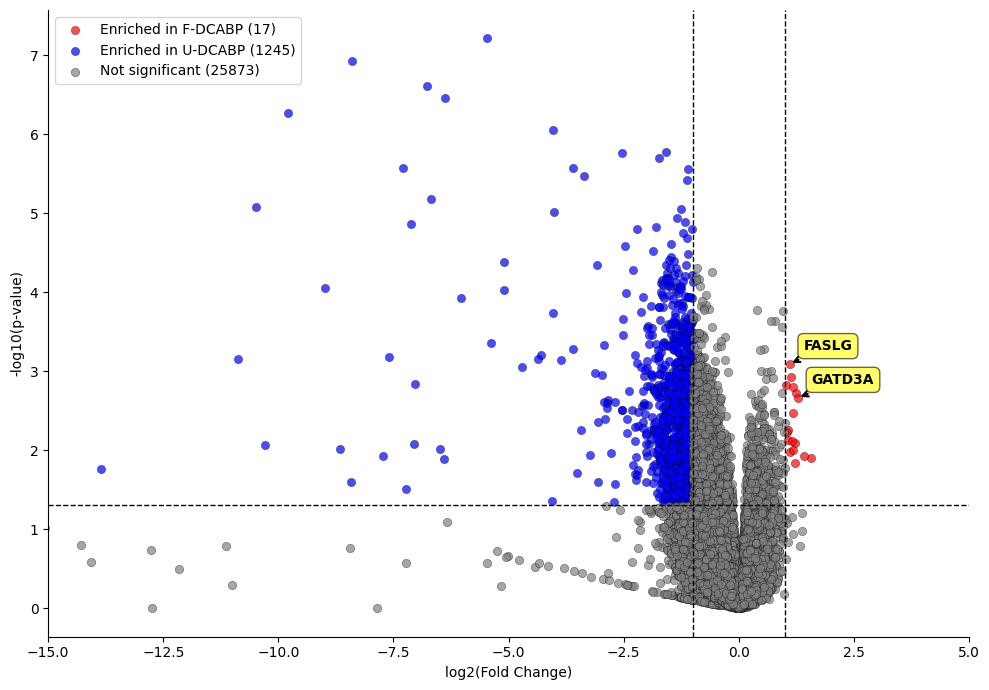

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Example: Load your DESeq2 results into a DataFrame
# Replace this with your actual DataFrame
df = df_DE.copy()  # e.g., pd.read_csv("deseq2_results.csv")

# Add -log10(p-value) for the y-axis
df["-log10(pvalue)"] = -np.log10(df["pvalue"])

# Set thresholds
logfc_thresh = 1
pval_thresh = 0.05

# Define significance
df["significant"] = "Not significant"
df.loc[(df["pvalue"] < pval_thresh) & (df["log2FoldChange"] > logfc_thresh), "significant"] = "Enriched in F-DCABP"
df.loc[(df["pvalue"] < pval_thresh) & (df["log2FoldChange"] < -logfc_thresh), "significant"] = "Enriched in U-DCABP"

# Count stats
up_count = (df["significant"] == "Enriched in F-DCABP").sum()
down_count = (df["significant"] == "Enriched in U-DCABP").sum()

# Plot
plt.figure(figsize=(10, 7))
colors = {"Not significant": "grey", "Enriched in F-DCABP": "red", "Enriched in U-DCABP": "blue"}

for label, group in df.groupby("significant"):
    plt.scatter(group["log2FoldChange"], group["-log10(pvalue)"],
                label=f"{label} ({len(group)})", color=colors[label],
                alpha=0.7, edgecolors='k', linewidths=0.3)

# Label only GATD3 and FASLG
genes_to_label = ["GATD3A",  "FASLG"]

for gene in genes_to_label:
    if gene in df.index:
        row = df.loc[gene]
        plt.annotate(gene,
                    xy=(row["log2FoldChange"], row["-log10(pvalue)"]),
                    xytext=(10, 10),  # offset in points
                    textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                              alpha=0.6, edgecolor='black'),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Add threshold lines
plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1)
plt.axvline(logfc_thresh, color='black', linestyle='--', linewidth=1)
plt.axvline(-logfc_thresh, color='black', linestyle='--', linewidth=1)

plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(p-value)")
plt.xlim([-15,5])
#plt.title("Volcano Plot")
plt.legend()
sns.despine()
plt.tight_layout()
#plt.savefig('volcano_Hypertopics_annotated.svg', dpi=300, bbox_inches='tight')

plt.show()

In [42]:
df_DE.sort_values('pvalue')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Geneid,,,,,,
RP4-594L9.2,7.763153,-5.461182,1.008598,-5.414629,6.141597e-08,0.001227
CTC-270D5.1,6.403509,-8.407994,1.587384,-5.296763,1.178737e-07,0.001227
CTD-2525I3.6,6.021916,-6.769115,1.311054,-5.163108,2.428824e-07,0.001686
LINC01299,8.332256,-6.380495,1.252299,-5.095026,3.486933e-07,0.001815
AC006445.11,3.792435,-9.795604,1.955301,-5.009769,5.449552e-07,0.002269
...,...,...,...,...,...,...
GAS5,171.672586,-0.000074,0.210534,-0.000350,9.997208e-01,0.999865
AC004009.3,1.525160,-0.000192,0.608964,-0.000316,9.997480e-01,NaN
LLPHP3,16.305409,0.000041,0.263159,0.000155,9.998766e-01,0.999973


# GSEA

In [55]:
idx_=df_DE.index.values

In [56]:
# After PyDESeq2 analysis
from gseapy import prerank

# Create ranked list from DESeq2 results
df_DE['rank'] = df_DE['stat'].values
rnk=df_DE.loc[idx_]['rank'].copy()
rnk=rnk.reset_index()
rnk.columns=['gene','score']
rnk=rnk.dropna()
rnk=rnk.sort_values('score', ascending=False)


In [57]:
import gseapy

# BTM

In [83]:
# Run GSEA on ranked list
gsea_res = prerank(
    rnk=rnk,
    gene_sets='../../../data/references/genesets/BTM_for_GSEA_20131008.gmt',
    permutation_num=1000,
    outdir='BTM',
    seed=42,
    threads=4
)

2026-02-02 15:28:58,011 [WARNING] Duplicated values found in preranked stats: 0.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [84]:
df_sorted=gsea_res.res2d.sort_values('NES', ascending=False)
df_sorted['abs_FDR']= np.abs(df_sorted['FDR q-val'])

In [85]:
df_sorted.tail(3)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,abs_FDR
26,prerank,cell adhesion (M51),-0.607448,-1.832768,0.00223,0.005505,0.026,28/34,30.40%,COL5A1;ARHGAP6;VWF;CDH11;MMRN1;CHL1;POSTN;PARV...,0.005505
25,prerank,enriched in myeloid cells and monocytes (M81),-0.610787,-1.846376,0.0,0.006034,0.019,19/32,23.00%,PROS1;EGF;PCSK6;MMRN1;THBS1;SNCA;PDGFA;TF;SELP...,0.006034
24,prerank,TBA (M26.0),-0.641861,-1.847056,0.002323,0.012068,0.019,13/23,23.21%,GIPC2;GUCY2C;HNF4A;CDH17;TINAG;HNF4G;HMGCS2;A1...,0.012068


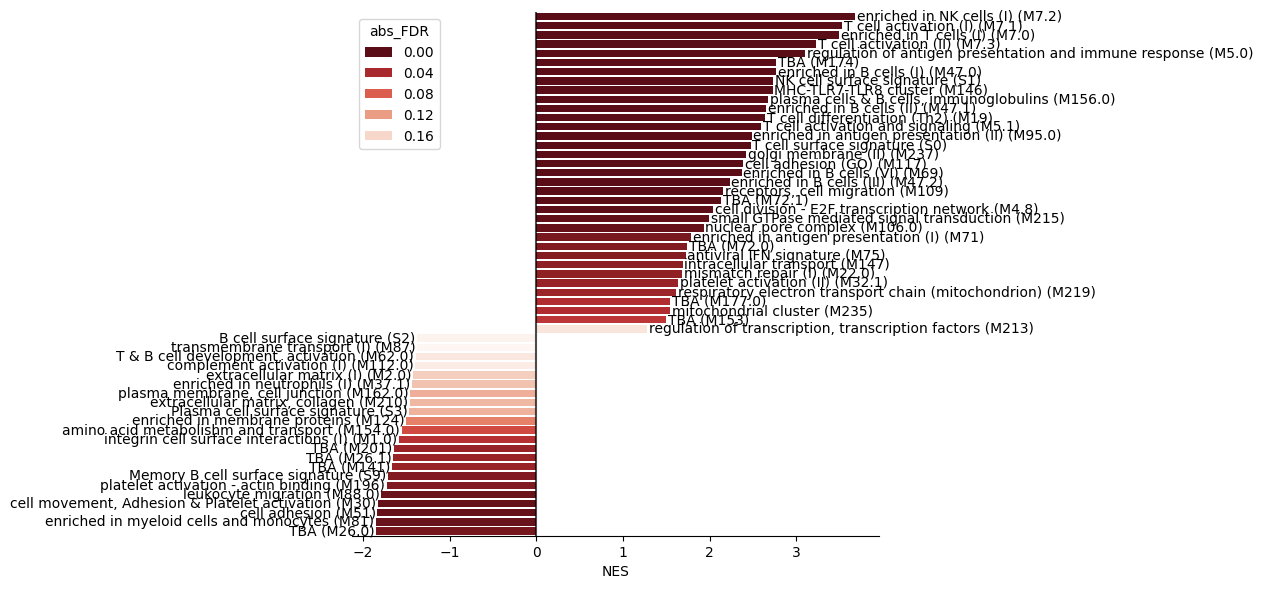

In [86]:
plt.figure(figsize=(12,6))

ax= sns.barplot(df_sorted[df_sorted.abs_FDR<0.2], x='NES', y=np.arange(len(df_sorted[df_sorted.abs_FDR<0.2])), orient='h', hue='abs_FDR', palette='Reds_r')
# Add term labels at the tip of each bar
for i, (idx, row) in enumerate(df_sorted[df_sorted.abs_FDR<0.2].iterrows()):
    x_pos = row['NES']
    # Adjust text position slightly beyond the bar tip
    offset = 0.02 if x_pos >= 0 else -0.02
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, i, row['Term'], va='center', ha=ha, fontsize=10)
    
# Remove y-axis
ax.set_ylabel('')
ax.set_yticks([])

# Add vertical line at NES=0
ax.axvline(x=0, color='black', linestyle='-', alpha=0.7)
sns.despine()
ax.spines['left'].set_visible(False)  # Remove left spine
ax.tick_params(left=False)  # Remove y-axis tick marks

plt.tight_layout()    

# C2 - Reactome

In [119]:
# Run GSEA on ranked list
gsea_res = prerank(
    rnk=rnk,
    gene_sets='../../../data/references/genesets/c2.cp.reactome.v2024.1.Hs.symbols.gmt',
    permutation_num=1000,
    outdir='C2',
    seed=42,
    threads=4
)

2026-02-02 15:41:56,832 [WARNING] Duplicated values found in preranked stats: 0.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [120]:
df_sorted=gsea_res.res2d.sort_values('NES', ascending=False)
df_sorted['abs_FDR']= np.abs(df_sorted['FDR q-val'])

In [121]:
df_sorted.tail(3)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,abs_FDR
52,prerank,REACTOME_NEUREXINS_AND_NEUROLIGINS,-0.576059,-1.871172,0.0,0.018316,0.078,29/54,23.82%,NLGN3;STXBP1;DLGAP2;DLGAP4;LRRTM3;NLGN4X;DLGAP...,0.018316
40,prerank,REACTOME_UNBLOCKING_OF_NMDA_RECEPTORS_GLUTAMAT...,-0.711276,-1.93763,0.0,0.007409,0.022,10/20,11.53%,GRIA2;ACTN2;GRIA4;LRRC7;GRIA3;DLG2;GRIN2C;GRIN...,0.007409
32,prerank,REACTOME_PROTEIN_PROTEIN_INTERACTIONS_AT_SYNAPSES,-0.590492,-2.011457,0.0,0.000617,0.001,46/81,23.82%,GRIA4;NLGN3;GRIA3;STXBP1;DLGAP2;PTPRD;DLGAP4;L...,0.000617


/var/folders/nm/zjh2_fld07sfnhxsrc8fykv0ply609/T/ipykernel_3276/3673970066.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


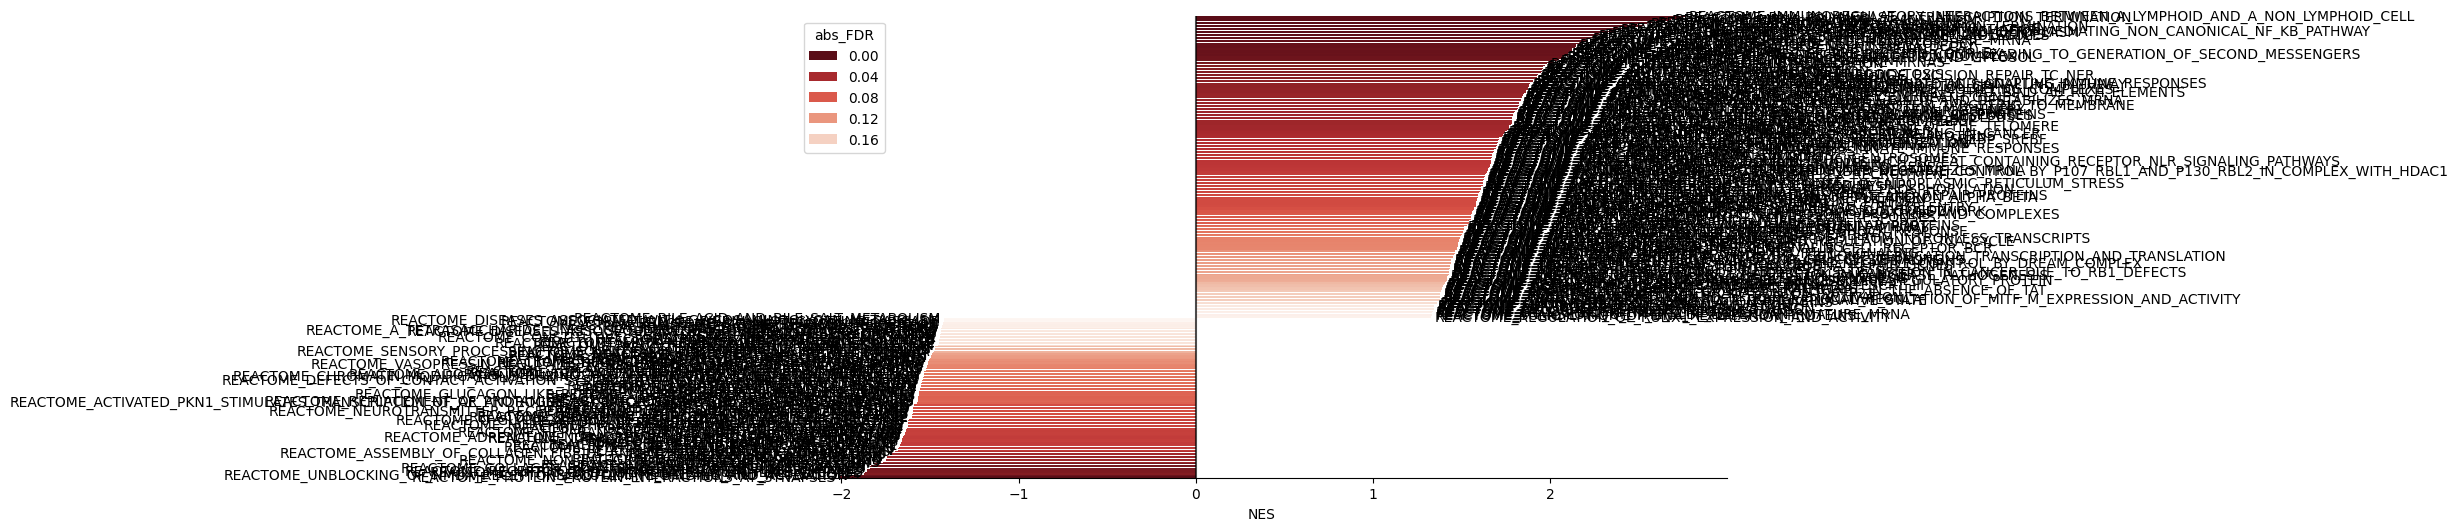

In [122]:
plt.figure(figsize=(12,6))

ax= sns.barplot(df_sorted[df_sorted.abs_FDR<0.2], x='NES', y=np.arange(len(df_sorted[df_sorted.abs_FDR<0.2])), orient='h', hue='abs_FDR', palette='Reds_r')
# Add term labels at the tip of each bar
for i, (idx, row) in enumerate(df_sorted[df_sorted.abs_FDR<0.2].iterrows()):
    x_pos = row['NES']
    # Adjust text position slightly beyond the bar tip
    offset = 0.02 if x_pos >= 0 else -0.02
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, i, row['Term'], va='center', ha=ha, fontsize=10)
    
# Remove y-axis
ax.set_ylabel('')
ax.set_yticks([])

# Add vertical line at NES=0
ax.axvline(x=0, color='black', linestyle='-', alpha=0.7)
sns.despine()
ax.spines['left'].set_visible(False)  # Remove left spine
ax.tick_params(left=False)  # Remove y-axis tick marks

plt.tight_layout()    
#plt.savefig('GSEA_Hypertopics_edad.png')